# MNIST Classification — 3-Layer CNN with einops / einsum

Every layer and operation (convolutions, pooling, linear maps) is implemented
explicitly with **einops** (`rearrange`, `reduce`) and **torch.einsum** — no
`nn.Conv2d`, `nn.Linear`, or `F.conv2d` anywhere.

## Architecture

| Stage | Operation | Output shape |
|---|---|---|
| Input | — | `(B, 1, 28, 28)` |
| Conv Block 1 | Conv2d(1→32, k=3, pad=1) → ReLU → MaxPool2d(2) | `(B, 32, 14, 14)` |
| Conv Block 2 | Conv2d(32→64, k=3, pad=1) → ReLU → MaxPool2d(2) | `(B, 64, 7, 7)` |
| Conv Block 3 | Conv2d(64→128, k=3, pad=1) → ReLU | `(B, 128, 7, 7)` |
| Flatten | `rearrange("b c h w -> b (c h w)")` | `(B, 6272)` |
| FC Head | Linear(6272→256) → ReLU → Dropout(0.5) → Linear(256→10) | `(B, 10)` |

**Trained for 5 epochs** (Adam, lr=1e-3, batch=128).

In [1]:
import numpy as np
import torch
import torch.nn.functional as F
import torchvision.datasets as datasets
from einops import rearrange, reduce

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## 1. Data loading

In [2]:
train_ds = datasets.MNIST(root="./data", train=True,  download=True)
test_ds  = datasets.MNIST(root="./data", train=False, download=True)

# Tensors with shape (N, 1, 28, 28), normalized to [0, 1]
X_train = torch.tensor(np.asarray(train_ds.data)).float().div_(255.0).unsqueeze(1)
y_train = torch.tensor(np.asarray(train_ds.targets), dtype=torch.long)
X_test  = torch.tensor(np.asarray(test_ds.data)).float().div_(255.0).unsqueeze(1)
y_test  = torch.tensor(np.asarray(test_ds.targets), dtype=torch.long)

print(f"Train: {tuple(X_train.shape)}   Test: {tuple(X_test.shape)}")

Train: (60000, 1, 28, 28)   Test: (10000, 1, 28, 28)


## 2. Einops / einsum building blocks

* **Conv2d** — unfold input into overlapping windows with `unfold`, then contract
  over `(C_in, kh, kw)` with `torch.einsum("bhwcij,o cij -> bhwo", ...)`.
* **MaxPool2d(2)** — `reduce(x, "b c (h p1) (w p2) -> b c h w", "max")`.
* **Linear** — `torch.einsum("...i,oi->...o", x, W) + b`.

In [3]:
def conv2d_einsum(x, w, b):
    """Conv2d (stride 1) via einsum. x:(B,Cin,H,W) w:(Cout,Cin,kh,kw) b:(Cout,)"""
    win = x.unfold(2, w.shape[-2], 1).unfold(3, w.shape[-1], 1)   # (B,Cin,H,W,kh,kw)
    win = rearrange(win, "b c h w kh kw -> b h w c kh kw")
    out = torch.einsum("bhwcij,o cij -> bhwo", win, w)           # (B,H,W,Cout)
    return rearrange(out + b, "b h w o -> b o h w")              # (B,Cout,H,W)


class EinsumConv2d(torch.nn.Module):
    """Conv2d(k, stride=1, padding=p) implemented with einops + einsum."""
    def __init__(self, cin, cout, kernel, padding=1):
        super().__init__()
        self.padding = padding
        self.weight = torch.nn.Parameter(torch.empty(cout, cin, kernel, kernel))
        self.bias   = torch.nn.Parameter(torch.zeros(cout))
        bound = (1.0 / (cin * kernel * kernel)) ** 0.5
        torch.nn.init.uniform_(self.weight, -bound, bound)

    def forward(self, x):
        if self.padding:
            x = F.pad(x, (self.padding,) * 4)
        return conv2d_einsum(x, self.weight, self.bias)


class EinsumLinear(torch.nn.Module):
    """Linear layer implemented with einsum."""
    def __init__(self, in_f, out_f):
        super().__init__()
        self.weight = torch.nn.Parameter(torch.empty(out_f, in_f))
        self.bias   = torch.nn.Parameter(torch.zeros(out_f))
        bound = (1.0 / in_f) ** 0.5
        torch.nn.init.uniform_(self.weight, -bound, bound)

    def forward(self, x):
        return torch.einsum("...i,oi->...o", x, self.weight) + self.bias


class EinsumMaxPool2d(torch.nn.Module):
    """2x2 max-pool via einops reduce."""
    def forward(self, x):
        return reduce(x, "b c (h p1) (w p2) -> b c h w", "max", p1=2, p2=2)

## 3. The 3-layer CNN

In [4]:
class MNISTCNN3(torch.nn.Module):
    """3-layer CNN built entirely from einops/einsum blocks."""
    def __init__(self):
        super().__init__()
        self.conv1 = EinsumConv2d(1, 32, kernel=3, padding=1)
        self.conv2 = EinsumConv2d(32, 64, kernel=3, padding=1)
        self.conv3 = EinsumConv2d(64, 128, kernel=3, padding=1)
        self.pool  = EinsumMaxPool2d()
        self.fc1   = EinsumLinear(128 * 7 * 7, 256)
        self.fc2   = EinsumLinear(256, 10)
        self.dropout = torch.nn.Dropout(0.5)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))        # (B, 32, 14, 14)
        x = self.pool(F.relu(self.conv2(x)))        # (B, 64, 7, 7)
        x = F.relu(self.conv3(x))                   # (B, 128, 7, 7)
        x = rearrange(x, "b c h w -> b (c h w)")    # (B, 6272)
        x = F.relu(self.fc1(x))                     # (B, 256)
        x = self.dropout(x)
        return self.fc2(x)                          # (B, 10)


model = MNISTCNN3().to(device)
print(model)
print(f"Total trainable parameters: {sum(p.numel() for p in model.parameters()):,}")

MNISTCNN3(
  (conv1): EinsumConv2d()
  (conv2): EinsumConv2d()
  (conv3): EinsumConv2d()
  (pool): EinsumMaxPool2d()
  (fc1): EinsumLinear()
  (fc2): EinsumLinear()
  (dropout): Dropout(p=0.5, inplace=False)
)
Total trainable parameters: 1,701,130


## 4. Training — 5 epochs

In [5]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = torch.nn.CrossEntropyLoss()
BATCH, EPOCHS = 128, 5

history = []
for epoch in range(EPOCHS):
    model.train()
    perm = torch.randperm(X_train.size(0))
    total_loss, correct, seen = 0.0, 0, 0
    for i in range(0, len(perm), BATCH):
        idx = perm[i:i + BATCH]
        xb, yb = X_train[idx].to(device), y_train[idx].to(device)
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(idx)
        correct += (logits.argmax(1) == yb).sum().item()
        seen += len(idx)
    history.append((epoch + 1, total_loss / seen, correct / seen * 100))
    print(f"Epoch {epoch+1}/{EPOCHS}  loss={total_loss/seen:.4f}  train_acc={correct/seen*100:.2f}%")

Epoch 1/5  loss=0.2053  train_acc=93.45%


Epoch 2/5  loss=0.0608  train_acc=98.13%


Epoch 3/5  loss=0.0437  train_acc=98.67%


Epoch 4/5  loss=0.0326  train_acc=99.02%


Epoch 5/5  loss=0.0281  train_acc=99.12%


## 5. Test-split accuracy

In [6]:
model.eval()
with torch.no_grad():
    all_logits, all_preds, correct = [], [], 0
    for i in range(0, len(X_test), 512):
        xb = X_test[i:i + 512].to(device)
        logits = model(xb)
        preds = logits.argmax(1)
        all_logits.append(logits.cpu())
        all_preds.append(preds.cpu())
        correct += (preds == y_test[i:i + 512].to(device)).sum().item()

test_acc = correct / len(y_test) * 100
all_logits = torch.cat(all_logits)
all_preds  = torch.cat(all_preds)

print(f"TEST SPLIT ACCURACY: {test_acc:.2f}%  ({correct}/{len(y_test)})")

TEST SPLIT ACCURACY: 99.17%  (9917/10000)


## 6. Sample 16 test images — 4×4 grid (ground truth vs prediction)

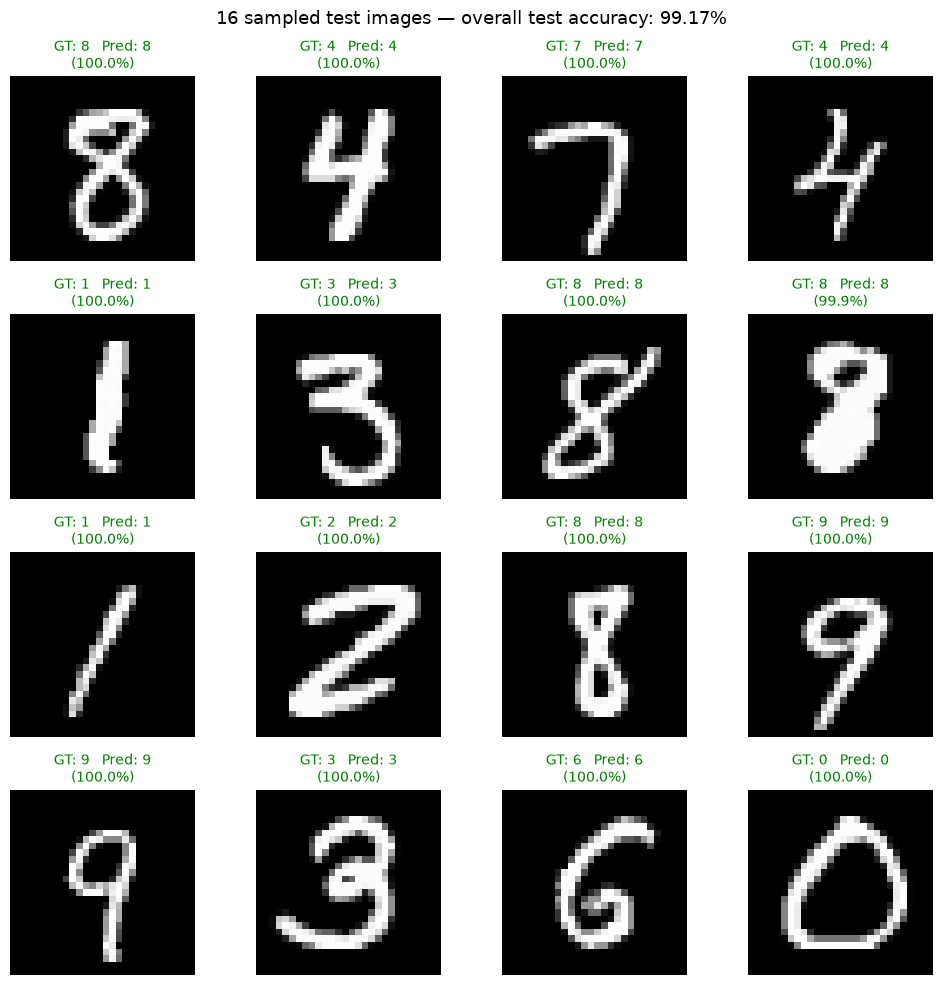

In [7]:
import matplotlib.pyplot as plt

sample_idx = torch.randperm(len(y_test))[:16]
imgs  = X_test[sample_idx].squeeze(1).numpy()
gt    = y_test[sample_idx].numpy()
preds = all_preds[sample_idx].numpy()
probs = all_logits[sample_idx].softmax(1).numpy()

fig, axes = plt.subplots(4, 4, figsize=(10, 10))
for ax, img, g, p, pr in zip(axes.ravel(), imgs, gt, preds, probs):
    ax.imshow(img, cmap="gray")
    color = "green" if g == p else "red"
    ax.set_title(f"GT: {g}   Pred: {p}\n({pr[p]*100:.1f}%)", color=color, fontsize=10)
    ax.axis("off")
fig.suptitle(f"16 sampled test images — overall test accuracy: {test_acc:.2f}%", fontsize=13)
plt.tight_layout()
plt.show()